# Original-parameter groups_only_vs_scale

Uses dimensional W (eq. `fecundity_dim`) and `fun_response` with original parameters
$a_1, a_2, b_1, b_2, h_{1a}, h_{1b}, h_{2a}, h_{2b}, M_1, M_2$.
Allometric scaling: `mass_ratio = b2/b1 = (h2a+h2b)/(h1a+h1b)` gives
`b1 = b2/mass_ratio` and `h1b = (h2a+h2b)/mass_ratio - h1a` (no A1/A2 correction).

In [9]:
Pkg.rm("PkgCite")

    Updating `~/Documents/Postdoc/Collaborations/CH_GroupFormation/CH_code/Julia_version/Project.toml`
  [50d0efc5] - PkgCite v0.1.4
    Updating `~/Documents/Postdoc/Collaborations/CH_GroupFormation/CH_code/Julia_version/Manifest.toml`
  [2027ae74] - BibInternal v0.3.7
  [13533e5b] - BibParser v0.2.3
  [f1be7e48] - Bibliography v0.2.20
  [5789e2e9] - FileIO v1.19.0
  [7d188eb4] - JSONSchema v1.5.0
  [50d0efc5] - PkgCite v0.1.4
  [69024149] - StringEncodings v0.3.7
  [1c621080] - TestItems v1.0.0
  [ddb6d928] - YAML v0.4.16
        Info We haven't cleaned this depot up for a bit, running Pkg.gc()...
      Active manifest files: 7 found
      Active artifact files: 192 found
      Active scratchspaces: 5 found
     Deleted 3 package installations (1.587 MiB)


In [123]:
using Revise
push!(LOAD_PATH, pwd()) # put current directory on path
using CooperativeHuntingPkg
using UnPack, Plots, LaTeXStrings, Measures, DifferentialEquations
default(
    guidefontsize=18,   # controls xlabel, ylabel, title font size
    tickfontsize=12,    # controls axis number labels
    legendfontsize=16,  # controls legend font
    linewidth=3,        # controls default line thickness
    grid = false,        # turns off grid in background
    dpi=600,
    fontfamily="Computer Modern" # font family that matches latex
)


# saving with bif diagrams
bif_fig_path = "../../CH_manuscript/FIgures/BifurcationDiagrams/"

param_label_dic[:mass_ratio] =L"Benefit Ratio, $b_1/b_2$"


L"Benefit Ratio, $b_1/b_2$"

In [137]:
# Base parameters in original (dimensional) units.
# a_i: attack rate, b_i: prey-to-predator conversion, h_ia/h_ib: handling time components.
# M1, M2: prey population sizes (in original density units).
# mass_ratio = b2/b1 = (h2a+h2b)/(h1a+h1b); b1 and h1b are derived from it.
params_base_orig = Dict{Symbol,Any}(
    :α1_of_1  => 0.05,    # capture prob of big prey by singleton
    :α2_of_1  => 1.0,    # capture prob of small prey (constant)
    :s1       => 2.0,     # group size where α1(x) = 0.5
    :a1       => 1.0,     # attack rate on big prey
    :a2       => 0.5,     # attack rate on small prey
    :b2       => 0.01,     # conversion rate for small prey
    :h1a      => 0.0,     # group-size-independent handling time, big prey
    :h2a      => 0.0,     # group-size-independent handling time, small prey
    :h2b      => 0.02,     # solo handling time (group-splittable) for small prey
    :mass_ratio => 5.0,   # m2/m1 = b2/b1; b1 and h1b derived from this
    :M1       => 80.0,    # big prey population density
    :M2       => 50.0,     # small prey population density
    :d        => 100.0,   # steepness of join/leave best-response function
    :x_max    => 15,
    :P        => 10.0,
    :Tg       => 0.01
)
# Derive b1 and h1b at the default mass_ratio
scale_parameters_orig(params_base_orig)

Dict{Symbol, Any} with 18 entries:
  :α1_of_1    => 0.05
  :a2         => 0.5
  :Tg         => 0.01
  :d          => 100.0
  :b2         => 0.01
  :s1         => 2.0
  :mass_ratio => 5.0
  :h1b        => 0.1
  :P          => 10.0
  :M1         => 80.0
  :α2_of_1    => 1.0
  :h2b        => 0.02
  :x_max      => 15
  :h1a        => 0.0
  :h2a        => 0.0
  :M2         => 50.0
  :b1         => 0.05
  :a1         => 1.0

In [ ]:
# Plot W(x) for several mass_ratio values
x = collect(1.0:1.0:params_base_orig[:x_max])
@unpack M1, M2 = params_base_orig

mass_ratio_list = [2, 3, 4]   # small/big mass ratio; ≈ scale 2, 5, 8
fig_orig_W = plot()
y_upper = 0
for (i, mr) in enumerate(mass_ratio_list)
    params = deepcopy(params_base_orig)
    params[:mass_ratio] = mr
    scale_parameters_orig(params)
    W = fun_W_orig(x, M1, M2, params)
    x_end_above = findlast(>=(W[1]), W)
    x_end_above = isnothing(x_end_above) ? 1 : x_end_above
    y_upper = maximum([y_upper, maximum(W)])
    plot!(1:x_end_above, W[1:x_end_above],
          color = i, marker = :circle, label = L"$m_1/m_2 = %$mr$")
    plot!(x[x_end_above:end], W[x_end_above:end],
          color = i, marker = :circle, linestyle = :dot, label = "")

end
plot!(xlab = "\n" * L"Group Size, $x$",
      ylab = L"$W$, per-capita fecundity",
      ylim = [0, 1.2*y_upper],
      legend = :bottomleft)
savefig(fig_orig_W, "../../CH_manuscript/FIgures/W_only_groups_vs_mass_ratio.pdf")
fig_orig_W

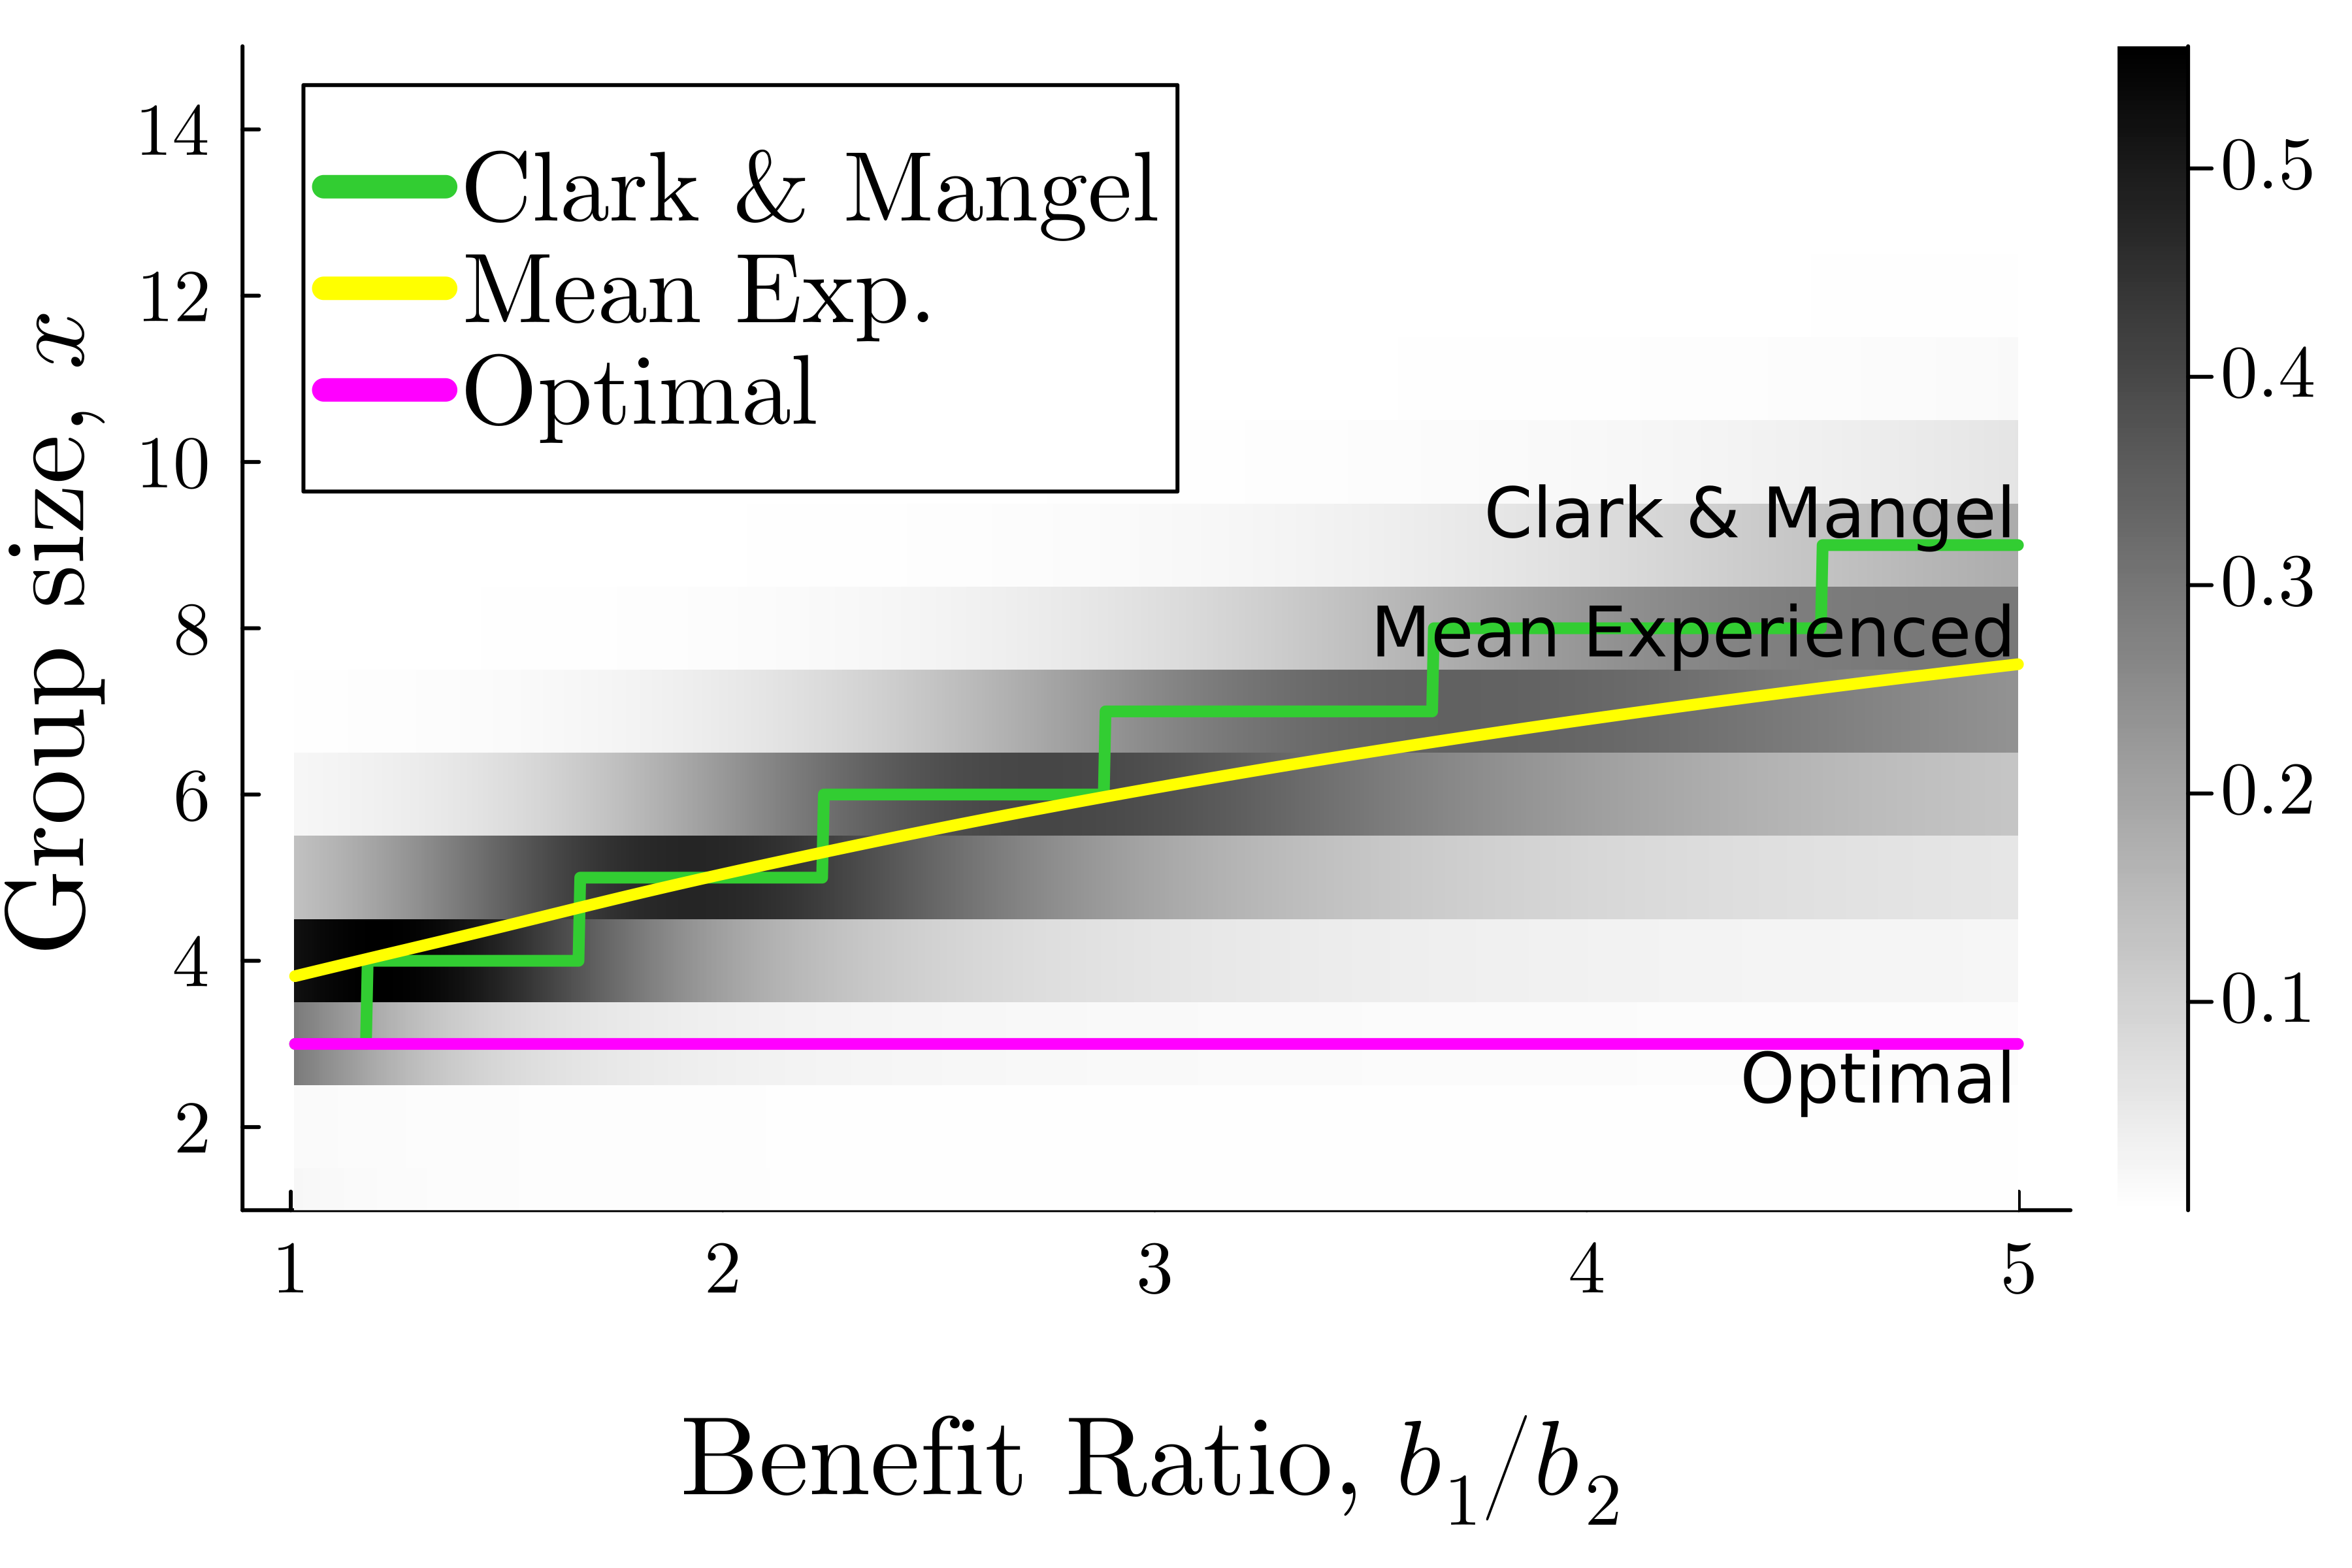

In [ ]:
function plot_hm_with_lines(prob, x_max, paramvec, paramkey,
            x_opt_vec, x_mc_vec, mean_x_vec; offsets = [+0.4, 0.4, -0.4]
        )

    hm = heatmap(
            paramvec,
            1:size(prob, 2),
            prob',
            c = cgrad([:white, :black], 256),
            xlabel = "\n" * param_label_dic[paramkey],
            ylabel = L"Group size, $x$",
            ylims = [1, x_max],
            bottom_margin=5mm
        )
    plot!(paramvec, x_mc_vec, label = "Clark & Mangel", color = :limegreen)
    plot!(paramvec, mean_x_vec, label = "Mean Exp.", color = :yellow)
    plot!(paramvec, x_opt_vec, label = "Optimal", color = :magenta)

    annotate!(paramvec[end-5], x_mc_vec[end] + offsets[1], text("Clark & Mangel", :black, :right, 12))
    annotate!(paramvec[end-5], mean_x_vec[end] + offsets[2], text("Mean Experienced", :black, :right, 12))
    annotate!(paramvec[end-5], x_opt_vec[end] + offsets[3], text("Optimal",        :black,   :right, 12))
    return hm

end
"""
Makes a heatmap of the probability of being in each group size at equilibria, 
in relation to the param specified by paramkey

offsets = [mangel clark offset, mean experienced offset, optimal W offset]
"""
function make_hm_versus_param_solve_g(
    paramkey, paramvec, params_base_orig; 
    t_f = 50000.0, offsets = [+0.4, 0.4, -0.4]
    )
    
    @unpack P, M1, M2, x_max = params_base_orig
    allow_births = get(params_base_orig, :allow_births, 0)

    xvec  = 1:x_max
    results_g = zeros(length(paramvec), x_max)
    params = deepcopy(params_base_orig)

    x_mc_vec = similar(paramvec)
    x_opt_vec = similar(paramvec)
    mean_x_vec = similar(paramvec)
    for (i, param) in enumerate(paramvec)
        params[paramkey] = param
        scale_parameters_orig(params)
        W    = fun_W_orig(xvec, M1, M2, params)
        gvec = get_g_equilibria_givenW(P, W, params)

        if allow_births != 0
            params[:Wvec] = W
            prob = ODEProblem(fun_dg_births_constantP_givenW!, gvec, (0.0, t_f), params)
            sol  = solve(prob)
            gvec = sol[:, end]
        end

        results_g[i, :] = gvec
        x_opt_vec[i] = argmax(W)
        x_mc_vec[i] = any(W[2:end] .< W[1]) ? findfirst(W[2:end] .< W[1]) : x_max
        mean_x_vec[i] = get_meanx(gvec, x_max)
    end

    prob = get_prob_in_x(results_g, P, x_max)

    hm = plot_hm_with_lines(
        prob, x_max, paramvec, paramkey, x_opt_vec, x_mc_vec, mean_x_vec;
        offsets = offsets
        )

end


# Equilibrium heatmap vs mass_ratio
paramkey  = :mass_ratio
paramvec  = collect(1.01:0.004:5.0)   # mass_ratio 0.1→1.0

# normal
hm1 = make_hm_versus_param_solve_g(
    paramkey, paramvec, params_base_orig; 
    offsets = [0.8,0.9,-0.7]
    )

# suppress leaving and pairing
params = deepcopy(params_base_orig)
params[:fuse_param] = 0.01
params[:leave_param] = 0.01
hm2 = make_hm_versus_param_solve_g(paramkey, paramvec, params)

## Add Births
methods(make_hm_versus_param_solve_g)
params_births = deepcopy(params_base_orig)
params_births[:allow_births] = 1
hm3 = make_hm_versus_param_solve_g(paramkey, paramvec, params_births)

# births with suppression of leaving and pairing
params_births = deepcopy(params_base_orig)
params_births[:allow_births] = 1
params_births[:fuse_param] = 0.01
params_births[:leave_param] = 0.01
hm4 = make_hm_versus_param_solve_g(paramkey, paramvec, params_births)

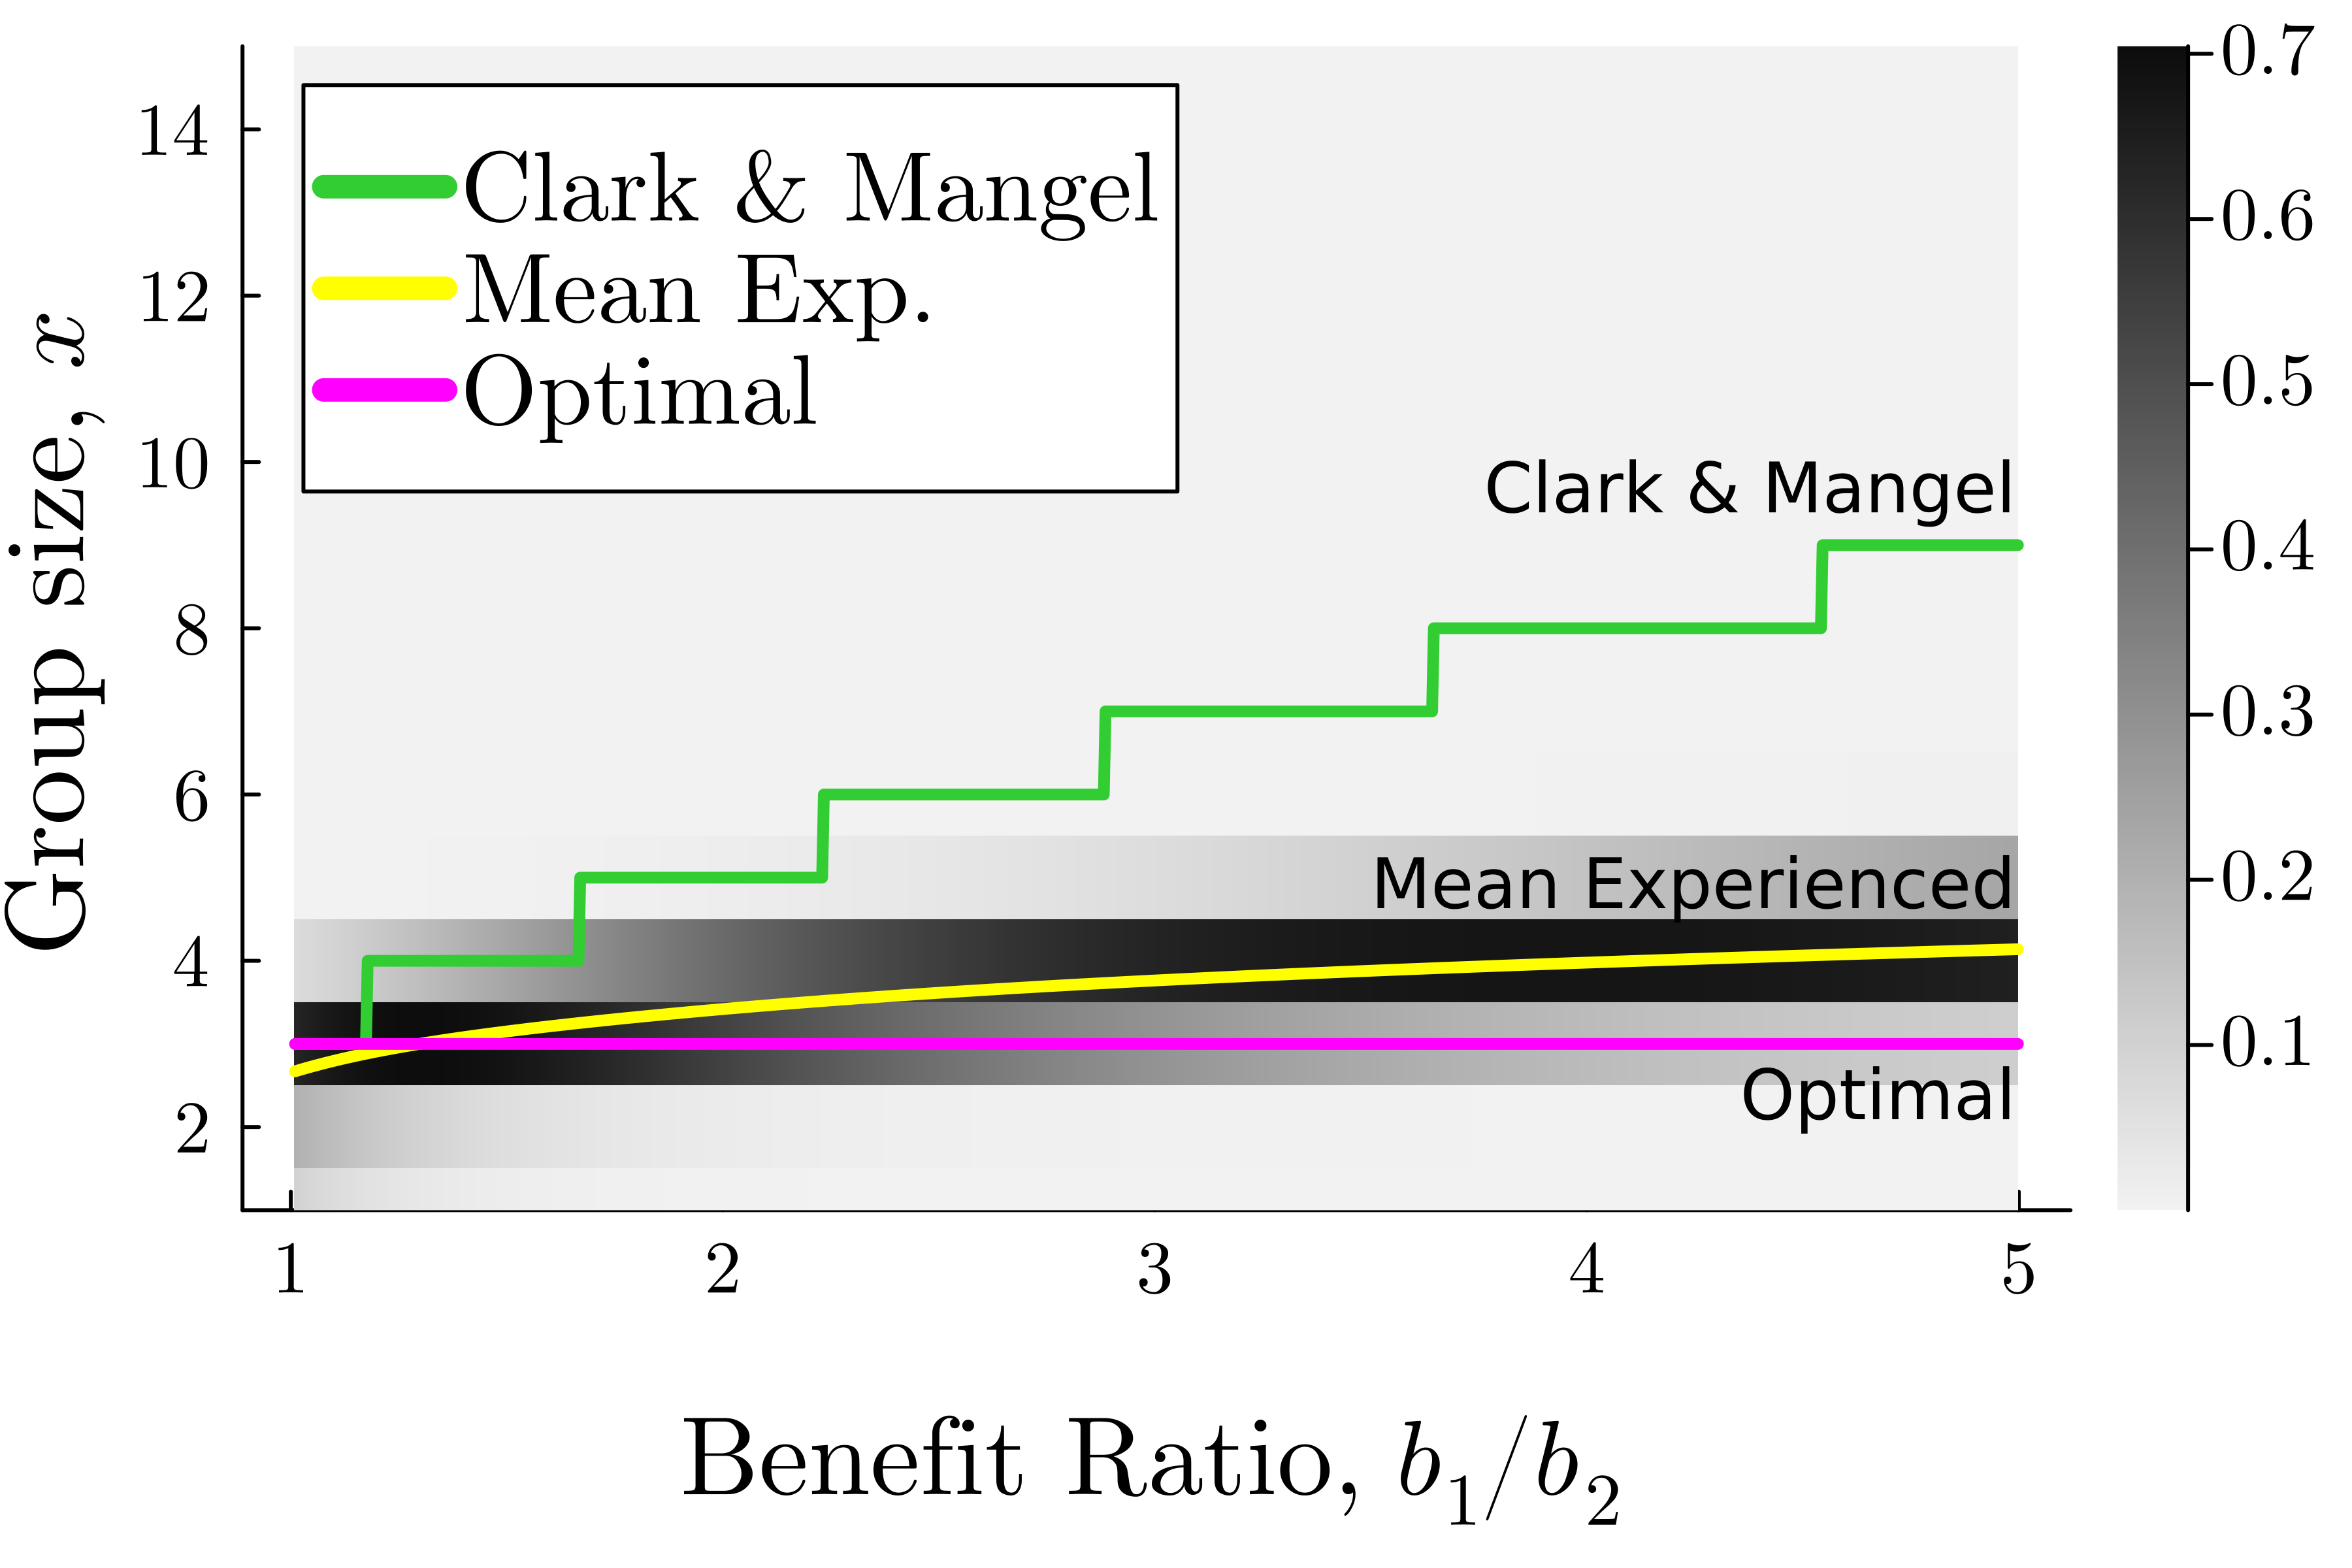

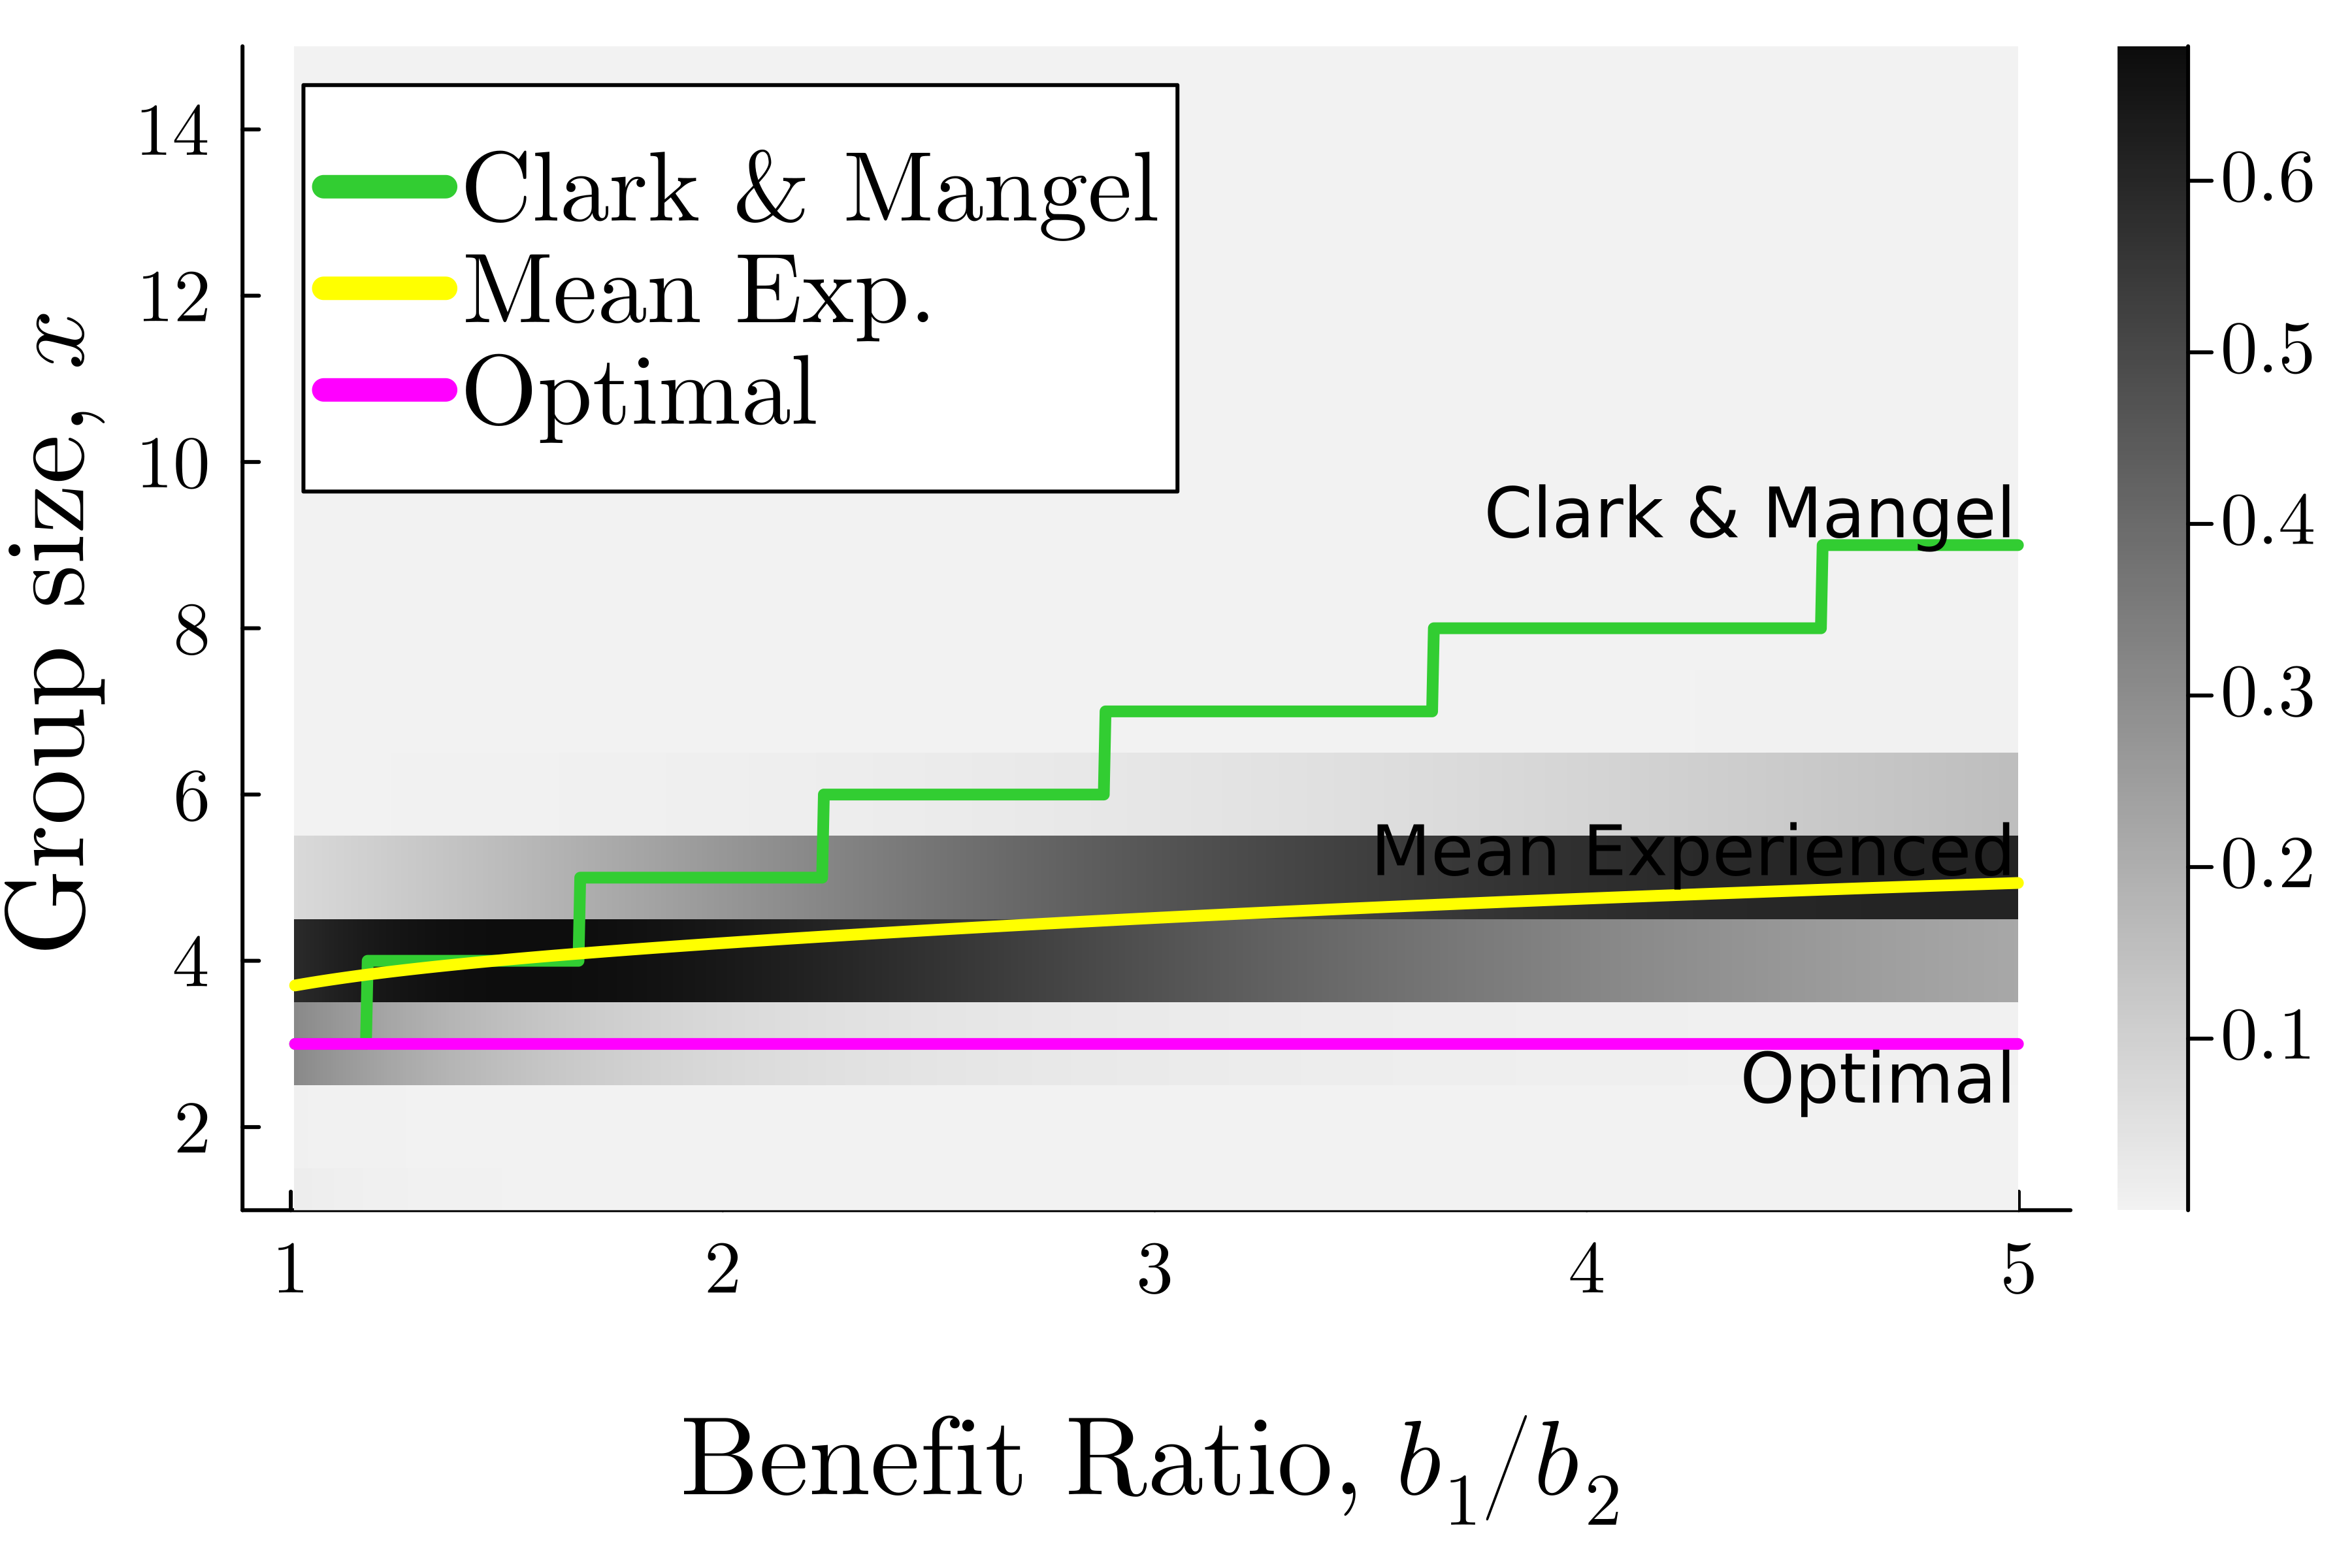

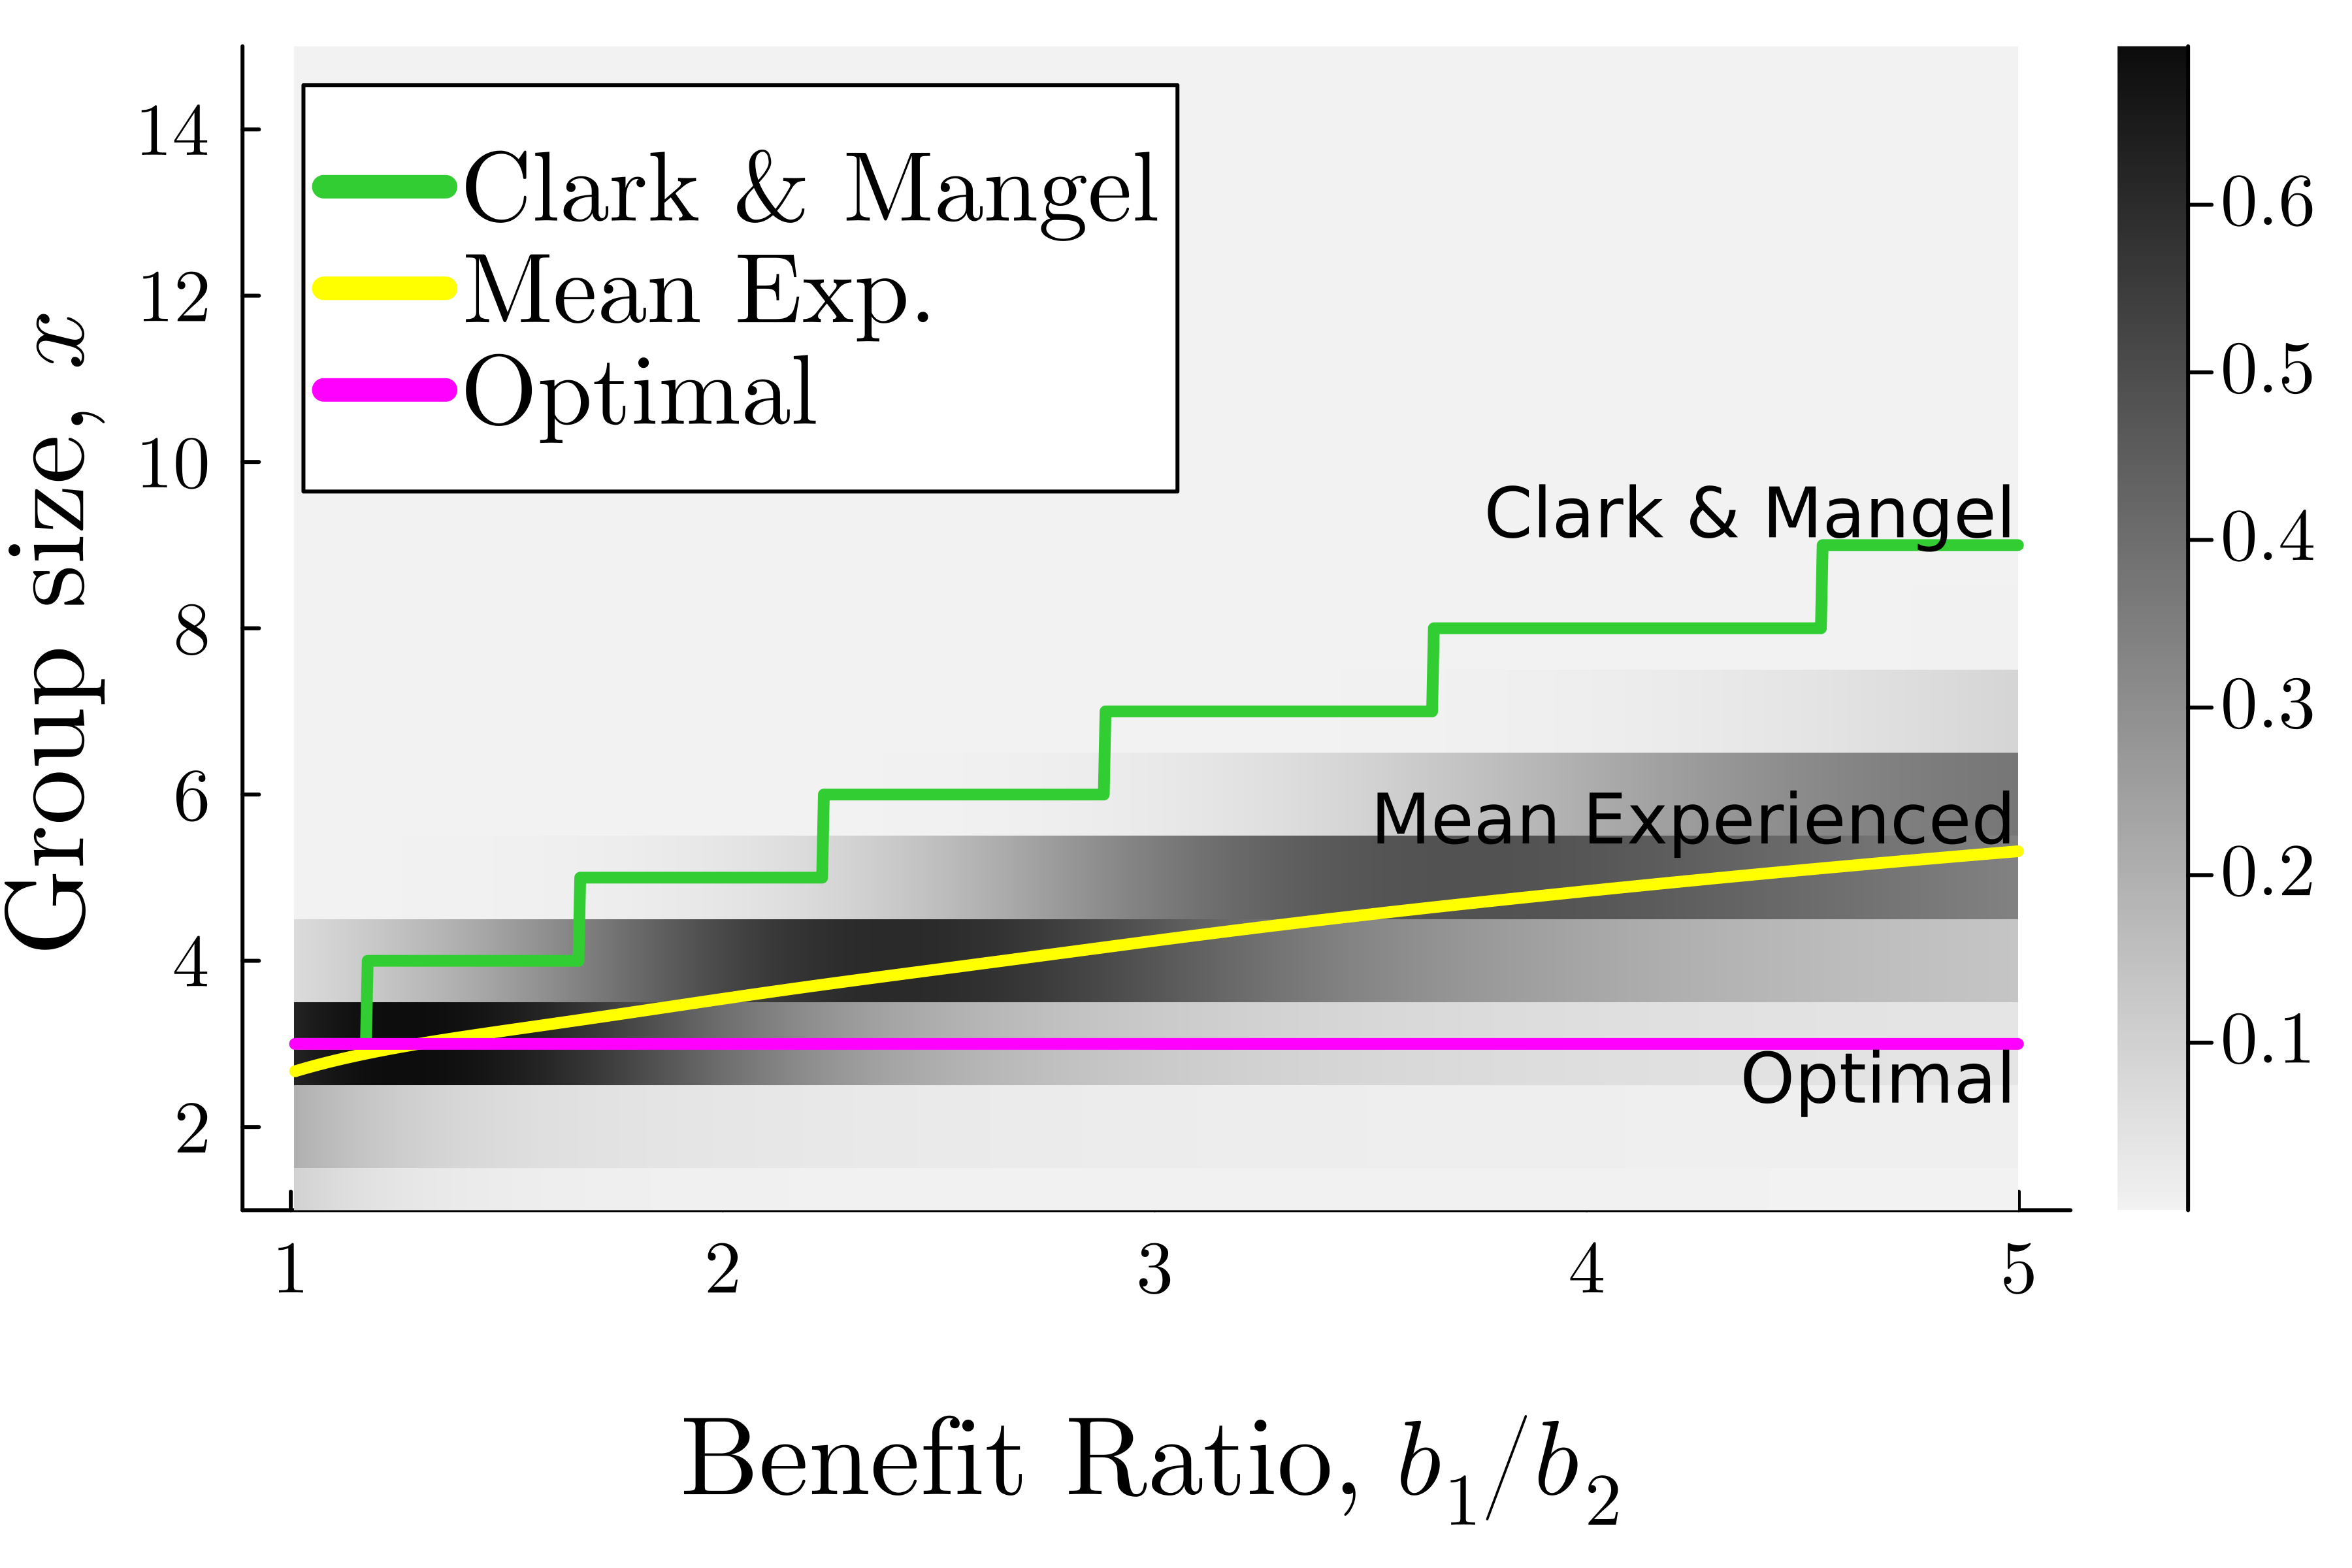

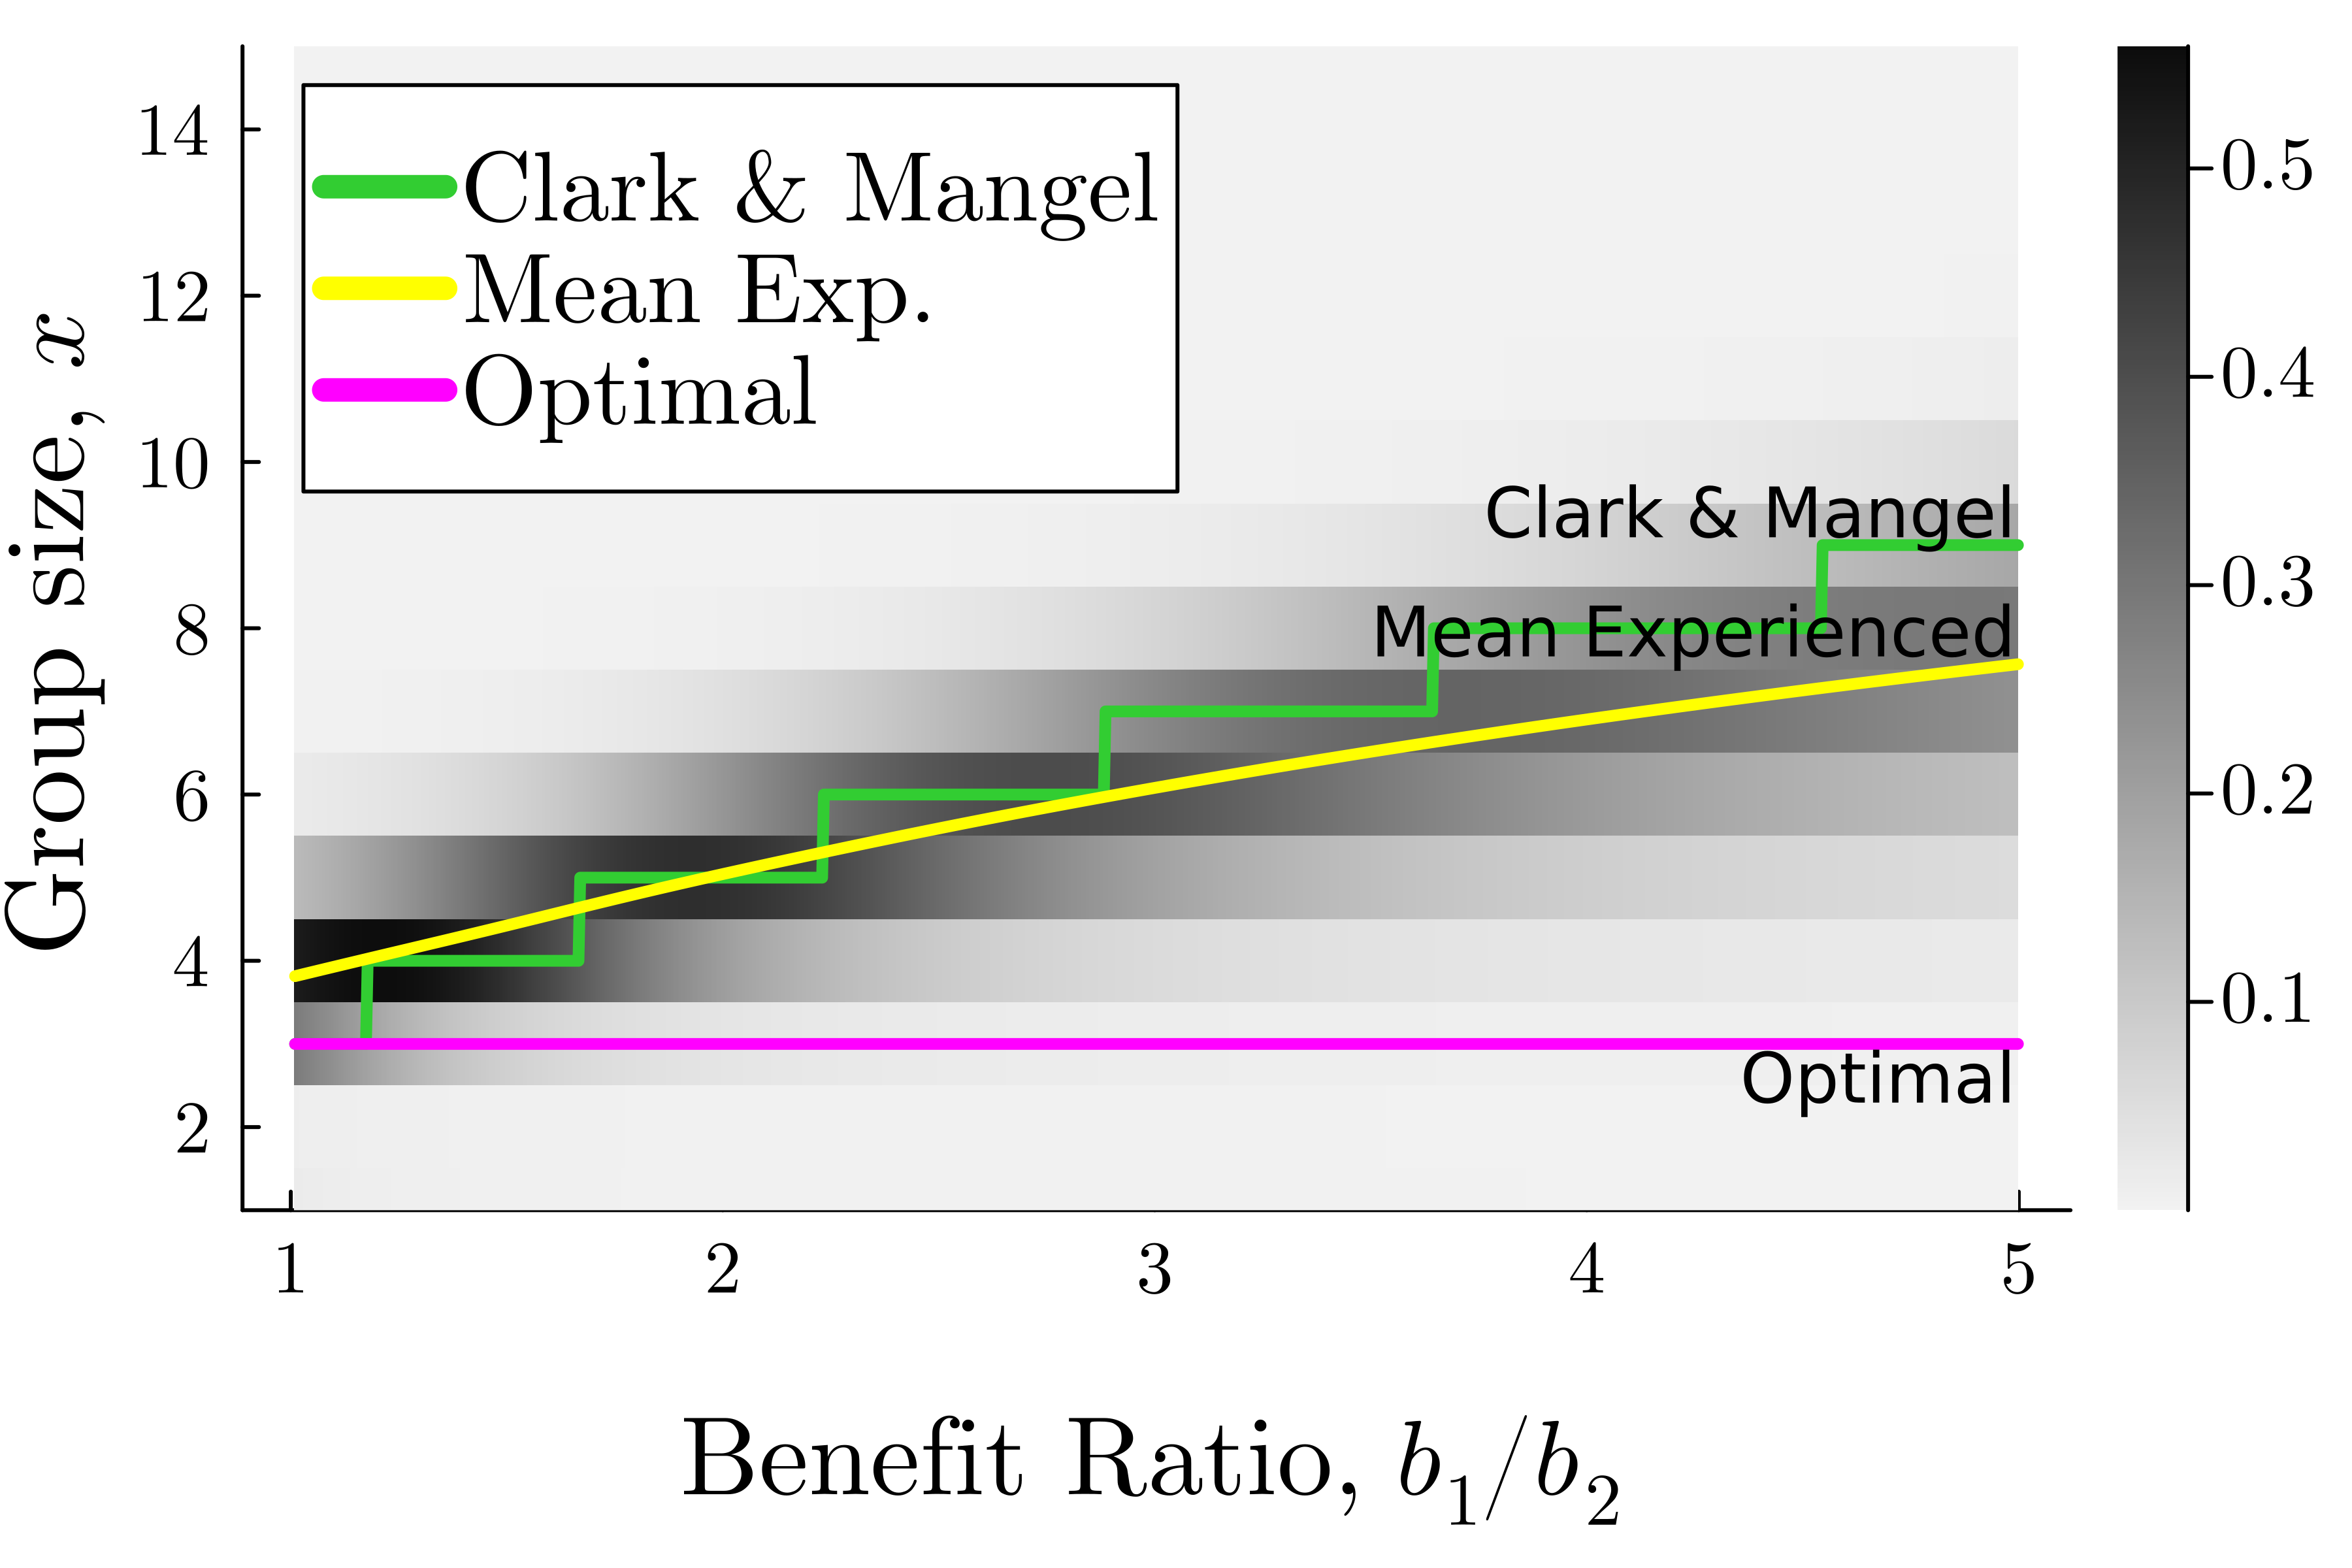

In [128]:
for hm in [hm1, hm2, hm3, hm4]
    display(hm)
end

In [ ]:
hm1
plot!(hm1, legend=false, tick_direction = :out, ylim = [1,10.5])
savefig(hm1, bif_fig_path*"equilibria_only_groups_vs_ratio.pdf")



"/Users/taliaborofsky/Documents/Postdoc/Collaborations/CH_GroupFormation/CH_manuscript/FIgures/BifurcationDiagrams/equilibria_only_groups_vs_ratio.pdf"

In [165]:
using Measures

clims = (0.0, 0.7)

# remove annotations of all panels except first one
for hm in [hm2, hm3, hm4]
    hm.subplots[1][:annotations] = []
end

p1 = plot( 
    plot(hm1; xlab = "",legend=false),
    plot(hm2; xlab = "", ylab = "", right_margin = 5mm, legend=false),
    plot(hm3; legend=false), 
    plot(hm4; ylab = "", legend = false); 
    clims = clims, colorbar = false,
    title = ["(A)\n" "(B)" "(C)\n" "(D)"], titlelocation = :left,
    titlefonthalign = :left,
    ylims = (0.5,10.5),
    legendfontsize = 12,
    tick_direction = :out
    )
p_cb = heatmap(fill(NaN, 2, 2); clims, c = cgrad([:white, :black], 256), colorbar=:right,
               framestyle=:none, ticks=false)
#plot!(hm1; legend = true)
p_full = plot(
    p1, p_cb; layout = grid(1, 2, widths=[0.94, 0.06]), size=(1080, 540), 
    bottom_margin = 8mm, left_margin = 5mm, legendfontsize=10
    )

savefig(p_full, bif_fig_path * "4heatmaps_ratio_orig.pdf")



GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT


"/Users/taliaborofsky/Documents/Postdoc/Collaborations/CH_GroupFormation/CH_manuscript/FIgures/BifurcationDiagrams/4heatmaps_ratio_orig.pdf"

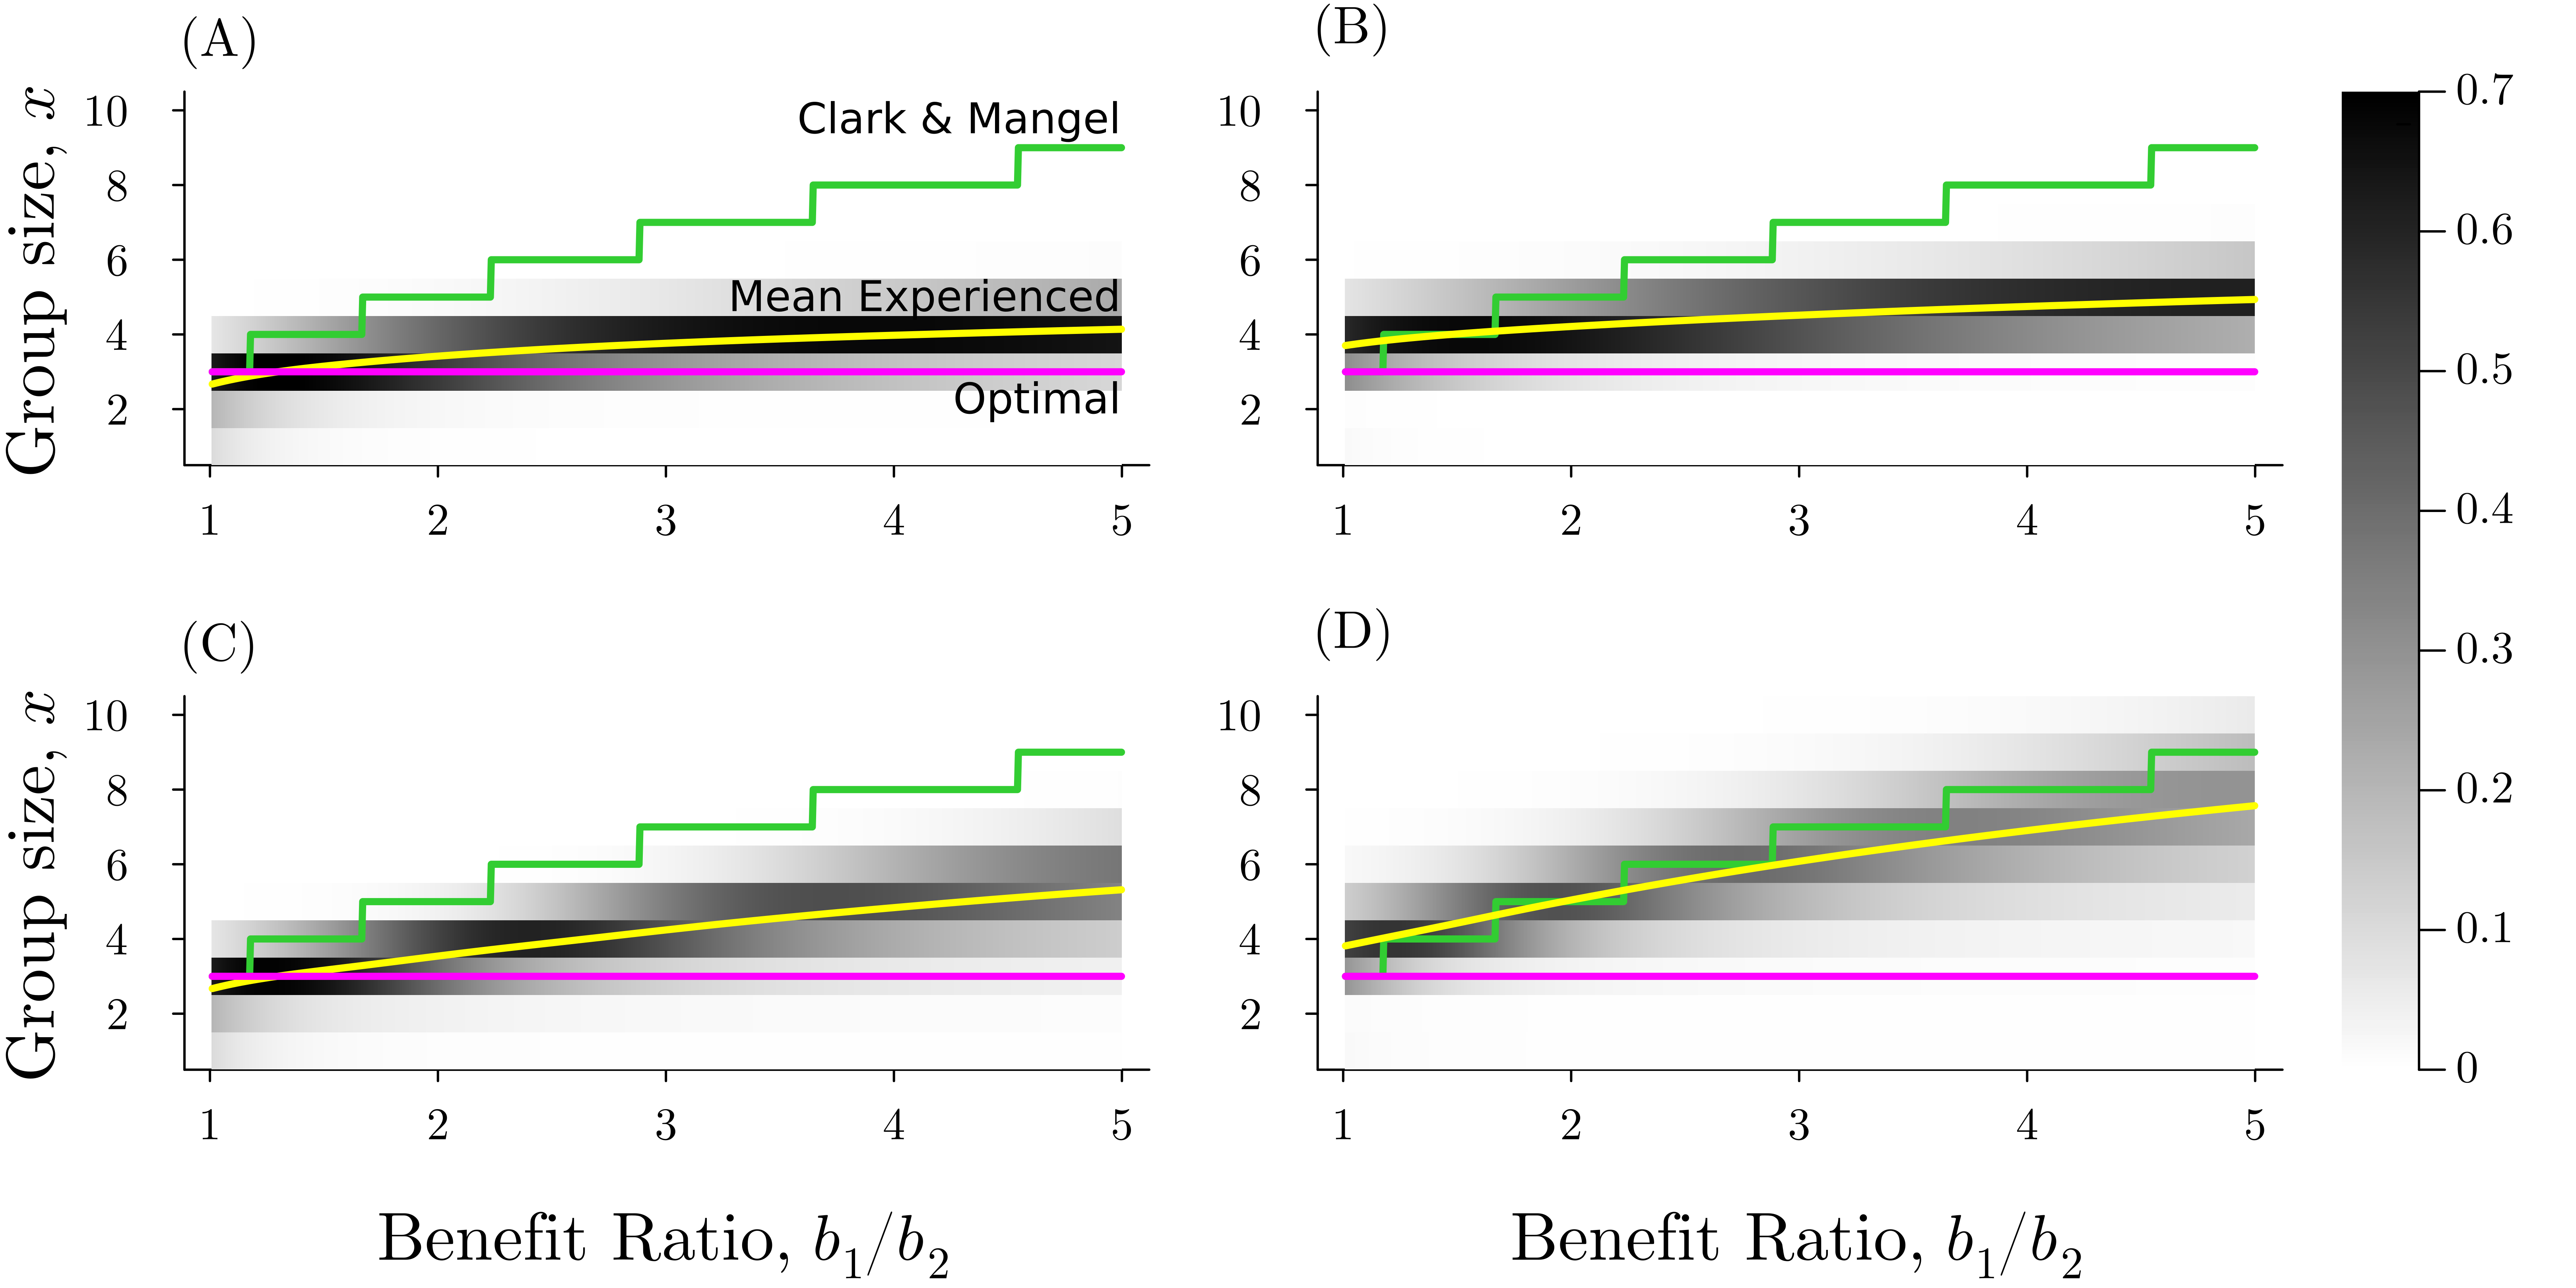

GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT


In [166]:
display(p_full)


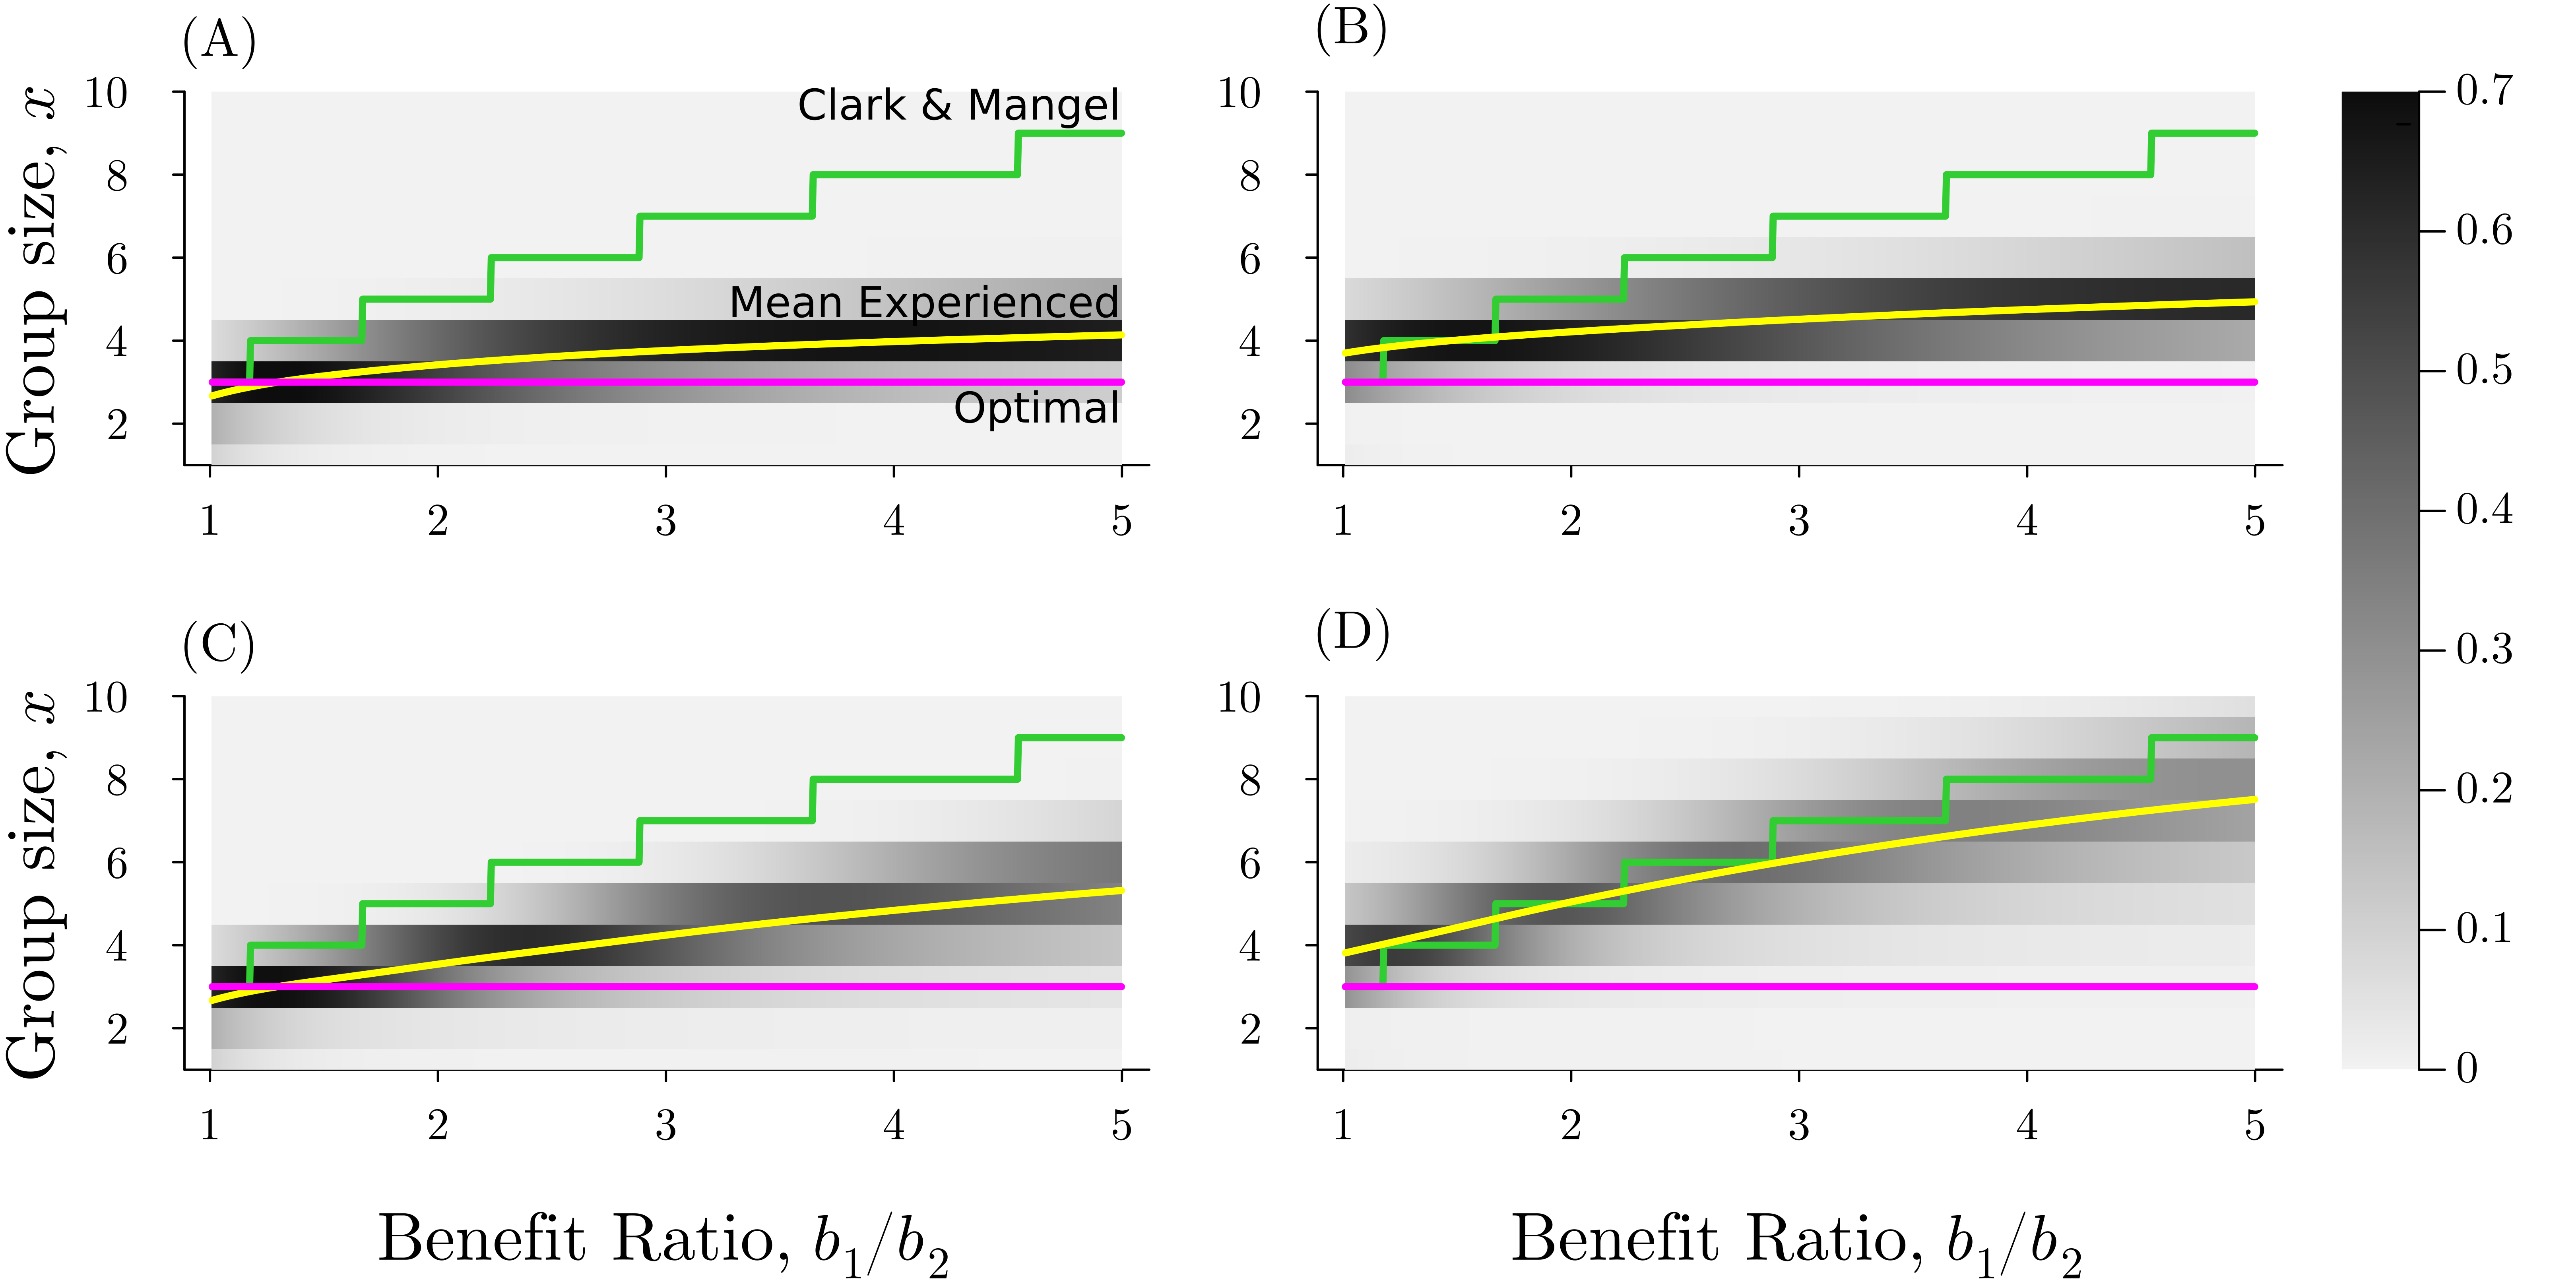

GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT


In [122]:
p_full